<a href="https://colab.research.google.com/github/habibiputrar/DeepLearning_B_2411531001_Habibi-Putra-Rizqullah/blob/main/Praktikum2/Praktikum2_DeepLearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Praktikum Minggu 2
## Convolutional Neural Network untuk Klasifikasi MNIST

**Nama:** Habibi Putra Rizqullah  
**NIM:** 2411531001

Notebook ini berisi implementasi CNN dua lapisan konvolusi sesuai Modul Praktikum Deep Learning Minggu 2. Model dilatih menggunakan MNIST, kemudian dievaluasi melalui loss, akurasi, dan contoh hasil prediksi.


### 1. Menyiapkan library dan perangkat

Sel ini memanggil library yang diperlukan. Seed dibuat tetap agar hasil lebih konsisten saat notebook dijalankan kembali. Jika GPU tersedia, proses pelatihan akan menggunakannya secara otomatis.


In [1]:
import random
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Perangkat yang digunakan: {device}")


Perangkat yang digunakan: cpu


### 2. Memuat dataset MNIST

Gambar diubah menjadi tensor lalu dinormalisasi dari rentang 0–1 menjadi sekitar -1 sampai 1. MNIST memiliki satu kanal warna dan ukuran asli 28 × 28 piksel. Data latih diacak, sedangkan data uji tidak perlu diacak.


In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

trainset = torchvision.datasets.MNIST(
    root="./data", train=True, download=True, transform=transform
)
testset = torchvision.datasets.MNIST(
    root="./data", train=False, download=True, transform=transform
)

trainloader = DataLoader(
    trainset, batch_size=64, shuffle=True, num_workers=0,
    pin_memory=torch.cuda.is_available()
)
testloader = DataLoader(
    testset, batch_size=64, shuffle=False, num_workers=0,
    pin_memory=torch.cuda.is_available()
)

print(f"Jumlah data latih : {len(trainset):,}")
print(f"Jumlah data uji   : {len(testset):,}")
print(f"Ukuran satu gambar: {trainset[0][0].shape}")


100%|██████████| 9.91M/9.91M [00:00<00:00, 15.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 496kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.39MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.50MB/s]

Jumlah data latih : 60,000
Jumlah data uji   : 10,000
Ukuran satu gambar: torch.Size([1, 28, 28])


### 3. Melihat contoh data

Sebelum membuat model, beberapa gambar ditampilkan untuk memastikan dataset dan label sudah terbaca dengan benar. Normalisasi dibalik saat gambar ditampilkan agar warnanya kembali normal.


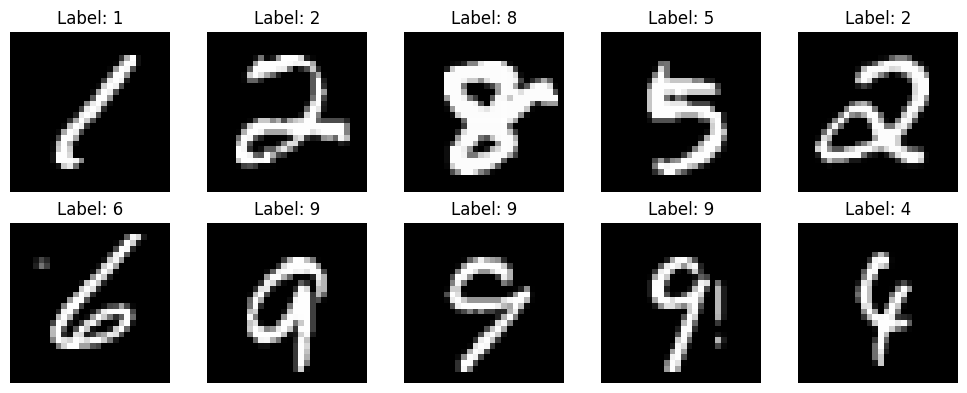

In [3]:
images, labels = next(iter(trainloader))

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for index, ax in enumerate(axes.flat):
    image = images[index].squeeze().numpy() * 0.5 + 0.5
    ax.imshow(image, cmap="gray")
    ax.set_title(f"Label: {labels[index].item()}")
    ax.axis("off")

plt.tight_layout()
plt.show()


### 4. Membuat model CNN

Model memakai dua lapisan konvolusi. Setiap konvolusi diikuti ReLU dan max pooling. Ukuran citra berubah dari 28 × 28 menjadi 14 × 14, lalu 7 × 7. Hasil ekstraksi fitur diratakan sebelum masuk ke dua lapisan fully connected.


In [4]:
class CNNModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


model = CNNModel().to(device)
print(model)


CNNModel(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1568, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)


### 5. Menyiapkan loss dan optimizer

CrossEntropyLoss digunakan karena masalah ini memiliki sepuluh kelas. Adam dipilih sebagai optimizer dengan learning rate 0,001 sesuai contoh pada modul.


In [5]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


### 6. Membuat fungsi training dan evaluasi

Fungsi `train_one_epoch` memperbarui bobot model menggunakan data latih. Fungsi `evaluate` hanya menghitung loss dan akurasi tanpa melakukan perubahan bobot.


In [6]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        predictions = outputs.argmax(dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, 100 * correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)
            predictions = outputs.argmax(dim=1)
            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    return total_loss / total, 100 * correct / total


### 7. Melatih model

Model dilatih selama lima epoch. Loss dan akurasi pada data latih serta data uji disimpan pada setiap epoch agar perkembangan model dapat dibandingkan.


In [7]:
epochs = 5
history = {
    "train_loss": [], "test_loss": [],
    "train_accuracy": [], "test_accuracy": []
}

start_time = time.perf_counter()

for epoch in range(epochs):
    train_loss, train_accuracy = train_one_epoch(
        model, trainloader, criterion, optimizer, device
    )
    test_loss, test_accuracy = evaluate(
        model, testloader, criterion, device
    )

    history["train_loss"].append(train_loss)
    history["test_loss"].append(test_loss)
    history["train_accuracy"].append(train_accuracy)
    history["test_accuracy"].append(test_accuracy)

    print(
        f"Epoch {epoch + 1}/{epochs} | "
        f"train loss: {train_loss:.4f} | "
        f"train acc: {train_accuracy:.2f}% | "
        f"test loss: {test_loss:.4f} | "
        f"test acc: {test_accuracy:.2f}%"
    )

training_time = time.perf_counter() - start_time
print()
print(f"Waktu training: {training_time:.2f} detik")


Epoch 1/5 | train loss: 0.1995 | train acc: 93.99% | test loss: 0.0624 | test acc: 97.96%
Epoch 2/5 | train loss: 0.0572 | train acc: 98.23% | test loss: 0.0480 | test acc: 98.37%
Epoch 3/5 | train loss: 0.0390 | train acc: 98.80% | test loss: 0.0383 | test acc: 98.78%
Epoch 4/5 | train loss: 0.0293 | train acc: 99.09% | test loss: 0.0312 | test acc: 99.03%
Epoch 5/5 | train loss: 0.0234 | train acc: 99.26% | test loss: 0.0313 | test acc: 99.00%

Waktu training: 267.38 detik


### 8. Menampilkan grafik hasil training

Grafik kiri menunjukkan perubahan loss, sedangkan grafik kanan menunjukkan akurasi. Jarak yang terlalu besar antara kurva training dan testing dapat menjadi tanda overfitting.


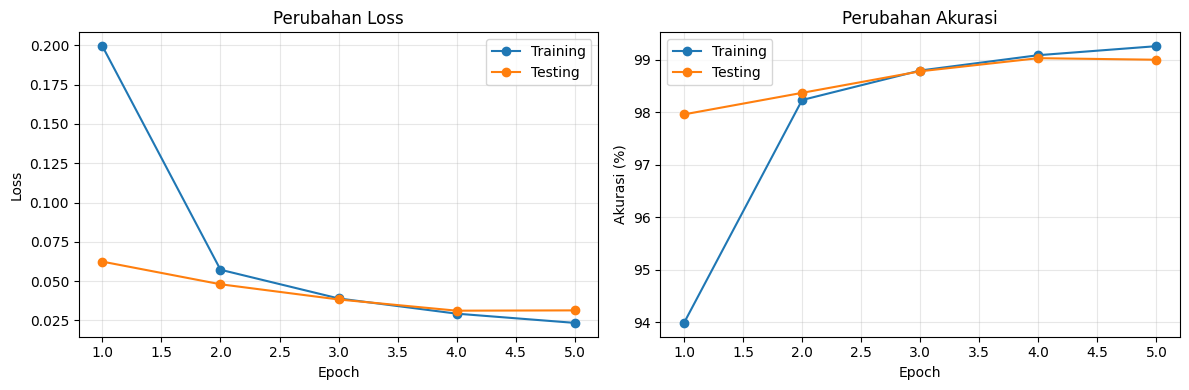

In [8]:
epoch_numbers = range(1, epochs + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epoch_numbers, history["train_loss"], marker="o", label="Training")
axes[0].plot(epoch_numbers, history["test_loss"], marker="o", label="Testing")
axes[0].set_title("Perubahan Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epoch_numbers, history["train_accuracy"], marker="o", label="Training")
axes[1].plot(epoch_numbers, history["test_accuracy"], marker="o", label="Testing")
axes[1].set_title("Perubahan Akurasi")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Akurasi (%)")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


### 9. Ringkasan evaluasi

Sel berikut menampilkan hasil akhir dan selisih akurasi training dengan testing. Selisih ini digunakan sebagai pemeriksaan sederhana, bukan satu-satunya bukti overfitting.


In [9]:
final_train_accuracy = history["train_accuracy"][-1]
final_test_accuracy = history["test_accuracy"][-1]
accuracy_gap = final_train_accuracy - final_test_accuracy

print(f"Akurasi training akhir : {final_train_accuracy:.2f}%")
print(f"Akurasi testing akhir  : {final_test_accuracy:.2f}%")
print(f"Selisih akurasi        : {accuracy_gap:.2f} poin persentase")

if accuracy_gap > 5:
    print("Indikasi: mulai terlihat overfitting karena selisih akurasi cukup besar.")
else:
    print("Indikasi: belum terlihat overfitting yang kuat dari selisih akurasi akhir.")


Akurasi training akhir : 99.26%
Akurasi testing akhir  : 99.00%
Selisih akurasi        : 0.26 poin persentase
Indikasi: belum terlihat overfitting yang kuat dari selisih akurasi akhir.


### 10. Menampilkan contoh prediksi

Sepuluh gambar dari data uji diprediksi oleh model. Judul berwarna hijau menandakan prediksi benar, sedangkan merah menandakan prediksi salah.


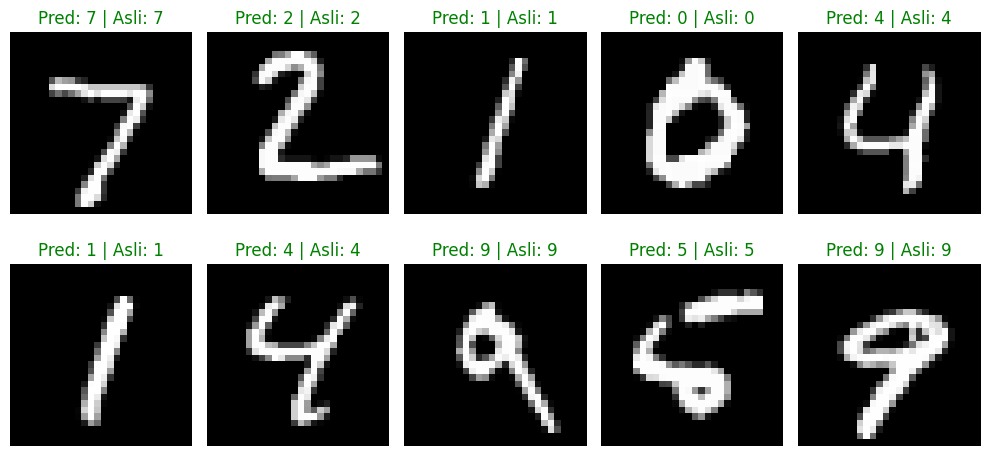

In [10]:
model.eval()
test_images, test_labels = next(iter(testloader))

with torch.no_grad():
    outputs = model(test_images.to(device))
    predictions = outputs.argmax(dim=1).cpu()

fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for index, ax in enumerate(axes.flat):
    image = test_images[index].squeeze().numpy() * 0.5 + 0.5
    is_correct = predictions[index].item() == test_labels[index].item()
    ax.imshow(image, cmap="gray")
    ax.set_title(
        f"Pred: {predictions[index].item()} | Asli: {test_labels[index].item()}",
        color="green" if is_correct else "red"
    )
    ax.axis("off")

plt.tight_layout()
plt.show()


### Analisis hasil

CNN dapat mengenali angka karena lapisan konvolusi mempelajari pola lokal seperti garis, lengkungan, dan sudut. Loss yang menurun menunjukkan proses optimasi berjalan, sedangkan peningkatan akurasi menunjukkan prediksi model semakin tepat. Penilaian overfitting dilakukan dengan membandingkan kurva dan selisih akurasi training serta testing yang dihasilkan saat notebook dijalankan.

### Jawaban pertanyaan reflektif

1. **Mengapa CNN lebih baik dibanding MLP untuk citra?**  
   CNN memanfaatkan hubungan spasial antar-piksel melalui filter yang dipakai berulang pada seluruh gambar. Jumlah parameternya juga lebih sedikit dibanding MLP yang harus menghubungkan setiap piksel ke neuron berikutnya.

2. **Apa fungsi pooling layer dalam CNN?**  
   Pooling mengurangi ukuran feature map sehingga perhitungan menjadi lebih ringan. Pooling juga mempertahankan fitur yang paling penting dan membuat model tidak terlalu sensitif terhadap sedikit pergeseran posisi objek.

3. **Bagaimana pengaruh ukuran kernel terhadap hasil konvolusi?**  
   Kernel kecil seperti 3 × 3 menangkap pola lokal dengan parameter yang lebih sedikit. Kernel 5 × 5 melihat area yang lebih luas dalam satu operasi, tetapi membutuhkan komputasi dan parameter lebih banyak. Ukuran kernel terbaik tetap perlu diuji karena bergantung pada data dan arsitektur.
